In [1]:
import os
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:

RAW_DIR = Path("/content/drive/MyDrive/complete_journey_data")

PREPROCESSED_DIR = RAW_DIR / "preprocessed"
FIGURES_DIR = PREPROCESSED_DIR / "figures"
REPORTS_DIR = PREPROCESSED_DIR / "reports"

PREPROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("RAW_DIR:", RAW_DIR)
print("PREPROCESSED_DIR:", PREPROCESSED_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("REPORTS_DIR:", REPORTS_DIR)

RAW_DIR: /content/drive/MyDrive/complete_journey_data
PREPROCESSED_DIR: /content/drive/MyDrive/complete_journey_data/preprocessed
FIGURES_DIR: /content/drive/MyDrive/complete_journey_data/preprocessed/figures
REPORTS_DIR: /content/drive/MyDrive/complete_journey_data/preprocessed/reports


## Raw File Loading

The file names are already known, so we define them directly.

We do not use dynamic file discovery here. This makes the notebook simpler and more stable for final submission.

### Files used in the main preprocessing pipeline

- `transactions.csv`
- `promotions.csv`
- `products.csv`
- `campaign_descriptions.csv`
- `demographics.csv`
- `coupons.csv`
- `campaigns.csv`
- `coupon_redemptions.csv`

### Files kept only for reference or testing

- `transactions_sample.csv`
- `promotions_sample.csv`
- `dataset_summary.csv`
- `test.txt`

The sample files are not used in the final cleaning or ETL output.

In [4]:
# 4. Define Exact Raw File Names

RAW_FILES = {
    "transactions": "transactions.csv",
    "promotions": "promotions.csv",
    "products": "products.csv",
    "campaign_descriptions": "campaign_descriptions.csv",
    "demographics": "demographics.csv",
    "coupons": "coupons.csv",
    "campaigns": "campaigns.csv",
    "coupon_redemptions": "coupon_redemptions.csv",
    "transactions_sample": "transactions_sample.csv",
    "promotions_sample": "promotions_sample.csv",
    "dataset_summary": "dataset_summary.csv"
}

MAIN_TABLES = [
    "transactions",
    "promotions",
    "products",
    "campaign_descriptions",
    "demographics",
    "coupons",
    "campaigns",
    "coupon_redemptions"
]

REFERENCE_TABLES = [
    "transactions_sample",
    "promotions_sample",
    "dataset_summary"
]


for table_name, file_name in RAW_FILES.items():
    file_path = RAW_DIR / file_name
    status = "FOUND" if file_path.exists() else "MISSING"
    print(f"{table_name:25s} -> {status:8s} -> {file_path}")

transactions              -> FOUND    -> /content/drive/MyDrive/complete_journey_data/transactions.csv
promotions                -> FOUND    -> /content/drive/MyDrive/complete_journey_data/promotions.csv
products                  -> FOUND    -> /content/drive/MyDrive/complete_journey_data/products.csv
campaign_descriptions     -> FOUND    -> /content/drive/MyDrive/complete_journey_data/campaign_descriptions.csv
demographics              -> FOUND    -> /content/drive/MyDrive/complete_journey_data/demographics.csv
coupons                   -> FOUND    -> /content/drive/MyDrive/complete_journey_data/coupons.csv
campaigns                 -> FOUND    -> /content/drive/MyDrive/complete_journey_data/campaigns.csv
coupon_redemptions        -> FOUND    -> /content/drive/MyDrive/complete_journey_data/coupon_redemptions.csv
transactions_sample       -> FOUND    -> /content/drive/MyDrive/complete_journey_data/transactions_sample.csv
promotions_sample         -> FOUND    -> /content/drive/MyDrive/c

In [5]:
# 5. Load Raw CSV Files

tables = {}

for table_name, file_name in RAW_FILES.items():
    file_path = RAW_DIR / file_name

    if not file_path.exists():
        print(f"WARNING: {file_name} was not found. Skipping {table_name}.")
        continue

    print(f"Loading {table_name} from {file_name} ...")
    tables[table_name] = pd.read_csv(file_path, low_memory=False)

print("\nLoaded tables:")
for table_name, df in tables.items():
    print(f"{table_name:25s} -> {df.shape[0]:,} rows, {df.shape[1]} columns")

Loading transactions from transactions.csv ...
Loading promotions from promotions.csv ...
Loading products from products.csv ...
Loading campaign_descriptions from campaign_descriptions.csv ...
Loading demographics from demographics.csv ...
Loading coupons from coupons.csv ...
Loading campaigns from campaigns.csv ...
Loading coupon_redemptions from coupon_redemptions.csv ...
Loading transactions_sample from transactions_sample.csv ...
Loading promotions_sample from promotions_sample.csv ...
Loading dataset_summary from dataset_summary.csv ...

Loaded tables:
transactions              -> 1,469,307 rows, 11 columns
promotions                -> 20,940,529 rows, 5 columns
products                  -> 92,331 rows, 7 columns
campaign_descriptions     -> 27 rows, 4 columns
demographics              -> 801 rows, 8 columns
coupons                   -> 116,204 rows, 3 columns
campaigns                 -> 6,589 rows, 2 columns
coupon_redemptions        -> 2,102 rows, 4 columns
transactions_sample

In [44]:
# 6. Inspect Column Names

for table_name in MAIN_TABLES:
    if table_name in tables:
        print(f"{table_name}.csv columns")
        print(list(tables[table_name].columns))

transactions.csv columns
['household_id', 'store_id', 'basket_id', 'product_id', 'quantity', 'sales_value', 'retail_disc', 'coupon_disc', 'coupon_match_disc', 'week', 'transaction_timestamp']
promotions.csv columns
['product_id', 'store_id', 'display_location', 'mailer_location', 'week']
products.csv columns
['product_id', 'manufacturer_id', 'department', 'brand', 'product_category', 'product_type', 'package_size']
campaign_descriptions.csv columns
['campaign_id', 'campaign_type', 'start_date', 'end_date']
demographics.csv columns
['household_id', 'age', 'income', 'home_ownership', 'marital_status', 'household_size', 'household_comp', 'kids_count']
coupons.csv columns
['coupon_upc', 'product_id', 'campaign_id']
campaigns.csv columns
['campaign_id', 'household_id']
coupon_redemptions.csv columns
['household_id', 'coupon_upc', 'campaign_id', 'redemption_date']


## Data Quality Helper Functions

The next cells define simple helper functions.

These helpers will:

- Profile table size, duplicates, missing values, and memory usage.
- Record issues found during preprocessing.
- Record cleaning actions taken.
- Save visualizations as image files.

The functions are intentionally simple and readable.

In [7]:
# 7. Helper Functions for Profiling and Reporting

data_quality_issues = []
cleaning_actions = []
table_profiles = []

def now_time():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def add_issue(table, issue_type, severity, message, affected_rows, action):
    data_quality_issues.append({
        "run_time": now_time(),
        "table": table,
        "issue_type": issue_type,
        "severity": severity,
        "message": message,
        "affected_rows": int(affected_rows),
        "action": action
    })


def add_action(table, problem, action_taken, reason):
    cleaning_actions.append({
        "table": table,
        "problem": problem,
        "action_taken": action_taken,
        "reason": reason
    })


def profile_table(df, table_name):
    duplicate_rows = int(df.duplicated().sum())
    missing_cells = int(df.isna().sum().sum())
    total_cells = int(df.shape[0] * df.shape[1])
    missing_percent = (missing_cells / total_cells * 100) if total_cells > 0 else 0
    memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

    table_profiles.append({
        "table": table_name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "duplicate_rows": duplicate_rows,
        "missing_cells": missing_cells,
        "missing_percent": round(missing_percent, 2),
        "memory_mb": round(memory_mb, 2)
    })


def save_current_plot(file_name):
    output_path = FIGURES_DIR / file_name
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {output_path}")

In [8]:
# 8. Profile Main Raw Tables

table_profiles = []

for table_name in MAIN_TABLES:
    if table_name in tables:
        profile_table(tables[table_name], f"raw_{table_name}")

raw_profile_df = pd.DataFrame(table_profiles)
raw_profile_df.sort_values("rows", ascending=False)

,table,rows,columns,duplicate_rows,missing_cells,missing_percent,memory_mb
1,raw_promotions,20940529,5,0,0,0.00,2476.34
0,raw_transactions,1469307,11,0,0,0.00,208.78
5,raw_coupons,116204,3,4872,0,0.00,2.66
2,raw_products,92331,7,0,31654,4.90,27.02
6,raw_campaigns,6589,2,0,0,0.00,0.10
7,raw_coupon_redemptions,2102,4,0,0,0.00,0.17
4,raw_demographics,801,8,0,370,5.77,0.29
3,raw_campaign_descriptions,27,4,0,0,0.00,0.00


## Raw Profiling Result

From the raw profiling output, we found the following:

1. `promotions.csv` is the largest file with more than 20 million rows.
2. `transactions.csv` has around 1.46 million transaction item rows.
3. `coupons.csv` has exact duplicate rows.
4. `products.csv` has missing descriptive product fields.
5. `demographics.csv` has missing household demographic fields.
6. The other small lookup tables are clean.

This is a normal situation in real retail data. The data is useful, but it needs controlled cleaning before ETL.

In [9]:
# 9. Column-Level Missing Value Report

missing_reports = []

for table_name in MAIN_TABLES:
    if table_name not in tables:
        continue

    df = tables[table_name]
    row_count = len(df)

    for col in df.columns:
        missing_count = int(df[col].isna().sum())

        if missing_count > 0:
            missing_reports.append({
                "table": f"raw_{table_name}",
                "column": col,
                "missing_count": missing_count,
                "missing_percent": round((missing_count / row_count) * 100, 2)
            })

missing_report_df = pd.DataFrame(missing_reports)
missing_report_df.sort_values("missing_count", ascending=False)

,table,column,missing_count,missing_percent
2,raw_products,package_size,30586,33.13
0,raw_products,product_category,540,0.58
1,raw_products,product_type,528,0.57
3,raw_demographics,home_ownership,233,29.09
4,raw_demographics,marital_status,137,17.10


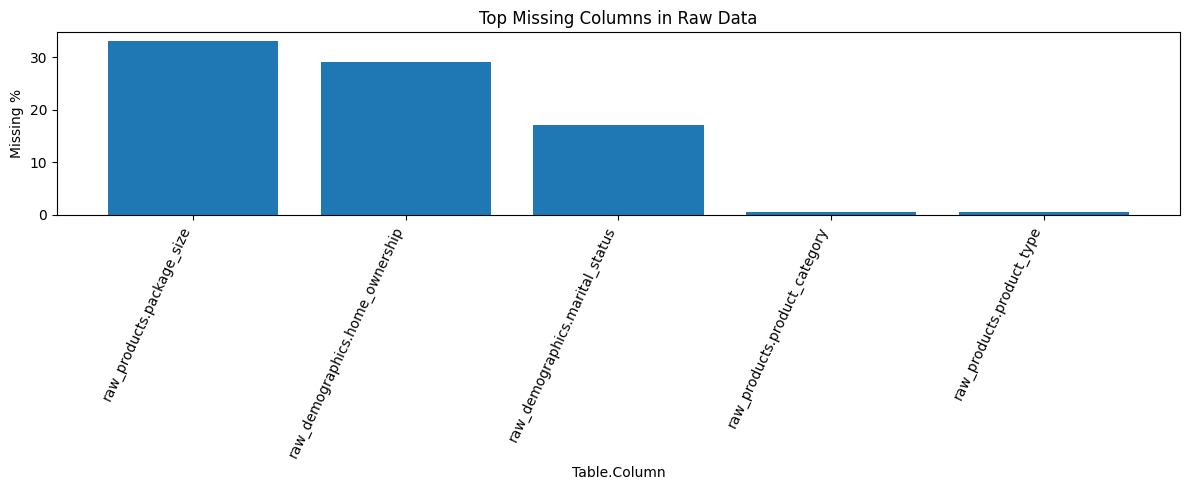

Saved figure: /content/drive/MyDrive/complete_journey_data/preprocessed/figures/top_missing_columns.png


In [10]:
# 10. Plot Top Missing Columns

if not missing_report_df.empty:
    top_missing = missing_report_df.sort_values("missing_percent", ascending=False).head(10).copy()
    top_missing["table_column"] = top_missing["table"] + "." + top_missing["column"]

    plt.figure(figsize=(12, 5))
    plt.bar(top_missing["table_column"], top_missing["missing_percent"])
    plt.title("Top Missing Columns in Raw Data")
    plt.xlabel("Table.Column")
    plt.ylabel("Missing %")
    plt.xticks(rotation=65, ha="right")
    save_current_plot("top_missing_columns.png")
else:
    print("No missing values found.")

## Missing Values Found

The missing values are concentrated in two tables:

### Products

- `package_size`: 30,586 missing values
- `product_category`: 540 missing values
- `product_type`: 528 missing values

These are descriptive categorical fields. We should not delete product rows because products are needed for transaction joins.

### Demographics

- `home_ownership`: 233 missing values
- `marital_status`: 137 missing values

These are household attributes. We should not delete households because that would bias customer segmentation.

### Handling decision

We fill missing categorical values with:

```text
Unknown
```

This keeps the rows and makes the missing information explicit.

## Cleaning Strategy

We only apply safe cleaning actions:

| Problem | Action |
|---|---|
| Duplicate rows in coupons | Remove exact duplicates |
| Missing product category/type/package size | Fill with `Unknown` |
| Missing demographic attributes | Fill with `Unknown` |
| Invalid quantity rows | Keep and report |
| Missing product references in transactions | Keep and report |
| Missing demographic references in transactions | Keep and report |
| Outliers | Report only |
| Coupon imbalance | Report only, no oversampling |

We avoid deleting transaction rows unless there is a strong business reason.

In [11]:
# 11. Prepare Cleaned Tables

cleaned_tables = {}

for table_name in MAIN_TABLES:
    if table_name in tables:
        cleaned_tables[table_name] = tables[table_name].copy()

print("Tables prepared for cleaning:")
for table_name in cleaned_tables:
    print(f"- {table_name}")

Tables prepared for cleaning:
- transactions
- promotions
- products
- campaign_descriptions
- demographics
- coupons
- campaigns
- coupon_redemptions


In [12]:
# 12. Clean Coupons: Remove Exact Duplicate Rows

if "coupons" in cleaned_tables:
    before_rows = len(cleaned_tables["coupons"])
    duplicate_rows = int(cleaned_tables["coupons"].duplicated().sum())

    if duplicate_rows > 0:
        cleaned_tables["coupons"] = cleaned_tables["coupons"].drop_duplicates()
        after_rows = len(cleaned_tables["coupons"])

        add_issue(
            table="coupons",
            issue_type="exact_duplicate_rows",
            severity="warning",
            message="Exact duplicate rows were found.",
            affected_rows=duplicate_rows,
            action="Removed exact duplicate rows."
        )

        add_action(
            table="coupons",
            problem="Exact duplicate rows",
            action_taken="Removed duplicates",
            reason="Exact duplicates add fake volume and bias analysis."
        )

        print(f"Coupons rows before cleaning: {before_rows:,}")
        print(f"Duplicate rows removed: {duplicate_rows:,}")
        print(f"Coupons rows after cleaning: {after_rows:,}")
    else:
        print("No duplicate rows found in coupons.")

Coupons rows before cleaning: 116,204
Duplicate rows removed: 4,872
Coupons rows after cleaning: 111,332


## Coupons Cleaning Result

We found duplicate rows in `coupons.csv`.

### Problem

The coupons table contained exact repeated records.

### Why this is a problem

If duplicated coupon records are kept, joins with campaigns, products, or coupon redemptions can produce repeated rows and incorrect coupon analysis.

### Solution

We removed only exact duplicate rows using `drop_duplicates()`.

This is safe because exact duplicates do not add new business information.

In [13]:
# 13. Clean Products: Fill Missing Categorical Values

if "products" in cleaned_tables:
    product_cols_to_fill = [
        "product_category",
        "product_type",
        "package_size"
    ]

    for col in product_cols_to_fill:
        if col in cleaned_tables["products"].columns:
            missing_before = int(cleaned_tables["products"][col].isna().sum())

            if missing_before > 0:
                cleaned_tables["products"][col] = cleaned_tables["products"][col].fillna("Unknown")
                missing_after = int(cleaned_tables["products"][col].isna().sum())

                add_issue(
                    table="products",
                    issue_type="missing_categorical_value",
                    severity="info",
                    message=f"Missing values found in '{col}'.",
                    affected_rows=missing_before,
                    action="Filled with Unknown."
                )

                add_action(
                    table="products",
                    problem=f"Missing {col}",
                    action_taken="Filled with Unknown",
                    reason="Unknown is safer than dropping useful products."
                )

                print(f"{col}: {missing_before:,} missing values filled. Remaining: {missing_after}")

product_category: 540 missing values filled. Remaining: 0
product_type: 528 missing values filled. Remaining: 0
package_size: 30,586 missing values filled. Remaining: 0


## Products Cleaning Result

The products table had missing values in product descriptive fields.

### Problem

Some products were missing values in:

- `package_size`
- `product_category`
- `product_type`

### Why we did not drop rows

Product rows are connected to transaction rows through `product_id`. Dropping products can break the product dimension and reduce the quality of sales analysis.

### Solution

We filled missing values with `Unknown`.

This keeps all products available for ETL and makes missing metadata visible.

In [14]:
# 14. Clean Demographics: Fill Missing Household Attributes

if "demographics" in cleaned_tables:
    demographic_cols_to_fill = [
        "home_ownership",
        "marital_status"
    ]

    for col in demographic_cols_to_fill:
        if col in cleaned_tables["demographics"].columns:
            missing_before = int(cleaned_tables["demographics"][col].isna().sum())

            if missing_before > 0:
                cleaned_tables["demographics"][col] = cleaned_tables["demographics"][col].fillna("Unknown")
                missing_after = int(cleaned_tables["demographics"][col].isna().sum())

                add_issue(
                    table="demographics",
                    issue_type="missing_demographic_value",
                    severity="info",
                    message=f"Missing values found in '{col}'.",
                    affected_rows=missing_before,
                    action="Filled with Unknown."
                )

                add_action(
                    table="demographics",
                    problem=f"Missing {col}",
                    action_taken="Filled with Unknown",
                    reason="Dropping customers would bias segmentation."
                )

                print(f"{col}: {missing_before:,} missing values filled. Remaining: {missing_after}")

home_ownership: 233 missing values filled. Remaining: 0
marital_status: 137 missing values filled. Remaining: 0


## Demographics Cleaning Result

The demographics table had missing values in household attributes.

### Problem

Some households were missing:

- `home_ownership`
- `marital_status`

### Why we did not drop rows

Household records are important for customer segmentation. Dropping them would make the segmentation biased toward only complete demographic records.

### Solution

We filled missing values with `Unknown`.

In [15]:
# 15. Convert Transaction Timestamp to Date Fields

if "transactions" in cleaned_tables:
    tx = cleaned_tables["transactions"]

    if "transaction_timestamp" in tx.columns:
        tx["transaction_datetime"] = pd.to_datetime(tx["transaction_timestamp"], errors="coerce", utc=True)
        tx["transaction_date"] = tx["transaction_datetime"].dt.date

        invalid_dates = int(tx["transaction_datetime"].isna().sum())

        if invalid_dates > 0:
            add_issue(
                table="transactions",
                issue_type="invalid_timestamp",
                severity="warning",
                message="Some transaction timestamps could not be parsed.",
                affected_rows=invalid_dates,
                action="Kept rows with null parsed datetime for review."
            )

        print("transaction_datetime and transaction_date were created.")
        print(f"Invalid parsed timestamps: {invalid_dates:,}")
    else:
        print("transaction_timestamp column was not found.")

transaction_datetime and transaction_date were created.
Invalid parsed timestamps: 0


## Transaction Date Handling

We created two new fields from `transaction_timestamp`:

- `transaction_datetime`
- `transaction_date`

These fields will help later in:

- daily sales analysis
- weekly trend analysis
- date dimension mapping
- holiday-aware analytics

The original timestamp column is kept.

In [16]:
# 16. Check Invalid Quantity Rows

if "transactions" in cleaned_tables and "quantity" in cleaned_tables["transactions"].columns:
    tx = cleaned_tables["transactions"]

    invalid_quantity_count = int((tx["quantity"] <= 0).sum())

    if invalid_quantity_count > 0:
        add_issue(
            table="transactions",
            issue_type="invalid_quantity",
            severity="warning",
            message="Quantity less than or equal to zero was found.",
            affected_rows=invalid_quantity_count,
            action="Kept rows, but flagged for analysis."
        )

        add_action(
            table="transactions",
            problem="Quantity <= 0",
            action_taken="Kept and flagged",
            reason="These rows may represent returns or corrections."
        )

    print(f"Rows with quantity <= 0: {invalid_quantity_count:,}")

Rows with quantity <= 0: 8,869


## Invalid Quantity Result

Some transaction rows have quantity less than or equal to zero.

### Why this can happen

In retail data, negative or zero quantities may represent:

- returns
- corrections
- cancelled items
- adjustment records

### Handling decision

We do not delete these records automatically.

We report them and keep them for business review because removing them can change total sales, basket behavior, and return/correction analysis.

In [17]:
# 17. Referential Integrity Checks

if "transactions" in cleaned_tables:
    tx = cleaned_tables["transactions"]

    # Check transactions.product_id against products.product_id
    if "products" in cleaned_tables and "product_id" in tx.columns and "product_id" in cleaned_tables["products"].columns:
        valid_products = set(cleaned_tables["products"]["product_id"].dropna().unique())
        missing_product_mask = ~tx["product_id"].isin(valid_products)
        missing_product_rows = int(missing_product_mask.sum())

        if missing_product_rows > 0:
            add_issue(
                table="transactions",
                issue_type="referential_integrity",
                severity="error",
                message="Some product_id values in transactions were not found in products.",
                affected_rows=missing_product_rows,
                action="Kept rows and reported issue. ETL may map missing products to Unknown Product."
            )

            add_action(
                table="transactions",
                problem="Missing parent key in products",
                action_taken="Kept and reported",
                reason="Fact records should not be deleted before business validation."
            )

        print(f"Transaction rows with product_id not found in products: {missing_product_rows:,}")

    # Check transactions.household_key against demographics.household_key
    if "demographics" in cleaned_tables and "household_key" in tx.columns and "household_key" in cleaned_tables["demographics"].columns:
        valid_households = set(cleaned_tables["demographics"]["household_key"].dropna().unique())
        missing_household_mask = ~tx["household_key"].isin(valid_households)
        missing_household_rows = int(missing_household_mask.sum())

        if missing_household_rows > 0:
            add_issue(
                table="transactions",
                issue_type="referential_integrity",
                severity="warning",
                message="Some household_key values in transactions were not found in demographics.",
                affected_rows=missing_household_rows,
                action="Kept rows and reported issue. ETL may map missing demographics to Unknown Household Profile."
            )

            add_action(
                table="transactions",
                problem="Missing parent key in demographics",
                action_taken="Kept and reported",
                reason="Not all customers have demographic records. This should not remove transaction facts."
            )

        print(f"Transaction rows with household_key not found in demographics: {missing_household_rows:,}")

Transaction rows with product_id not found in products: 4,836


## Referential Integrity Result

We checked whether transaction keys exist in the parent lookup tables.

### Product reference issue

Some transaction rows have `product_id` values that do not exist in `products.csv`.

This is treated as an error because product details are important for product analysis and market basket analysis.

### Household demographic reference issue

Many transaction rows have `household_key` values that do not exist in `demographics.csv`.

This is expected because demographic information is usually available for only a subset of households.

### Handling decision

We keep the transaction rows and report the issue.

In the ETL layer, we can map missing parent records to:

- `Unknown Product`
- `Unknown Household Profile`

This preserves sales facts without hiding data quality issues.

In [18]:
# 18. Coupon Usage Imbalance Check

if "transactions" in cleaned_tables and "coupon_disc" in cleaned_tables["transactions"].columns:
    tx = cleaned_tables["transactions"]

    coupon_used_count = int((tx["coupon_disc"].abs() > 0).sum())
    total_rows = len(tx)
    coupon_used_percent = (coupon_used_count / total_rows) * 100 if total_rows > 0 else 0

    if coupon_used_percent < 5:
        add_issue(
            table="transactions",
            issue_type="class_imbalance",
            severity="info",
            message=f"Coupon usage appears rare: {coupon_used_percent:.2f}% of rows.",
            affected_rows=coupon_used_count,
            action="Reported only. No oversampling applied in preprocessing."
        )

        add_action(
            table="transactions",
            problem="Coupon usage imbalance",
            action_taken="Reported without oversampling",
            reason="ETL data must preserve real business distribution."
        )

    print(f"Coupon used rows: {coupon_used_count:,}")
    print(f"Coupon used percentage: {coupon_used_percent:.2f}%")

Coupon used rows: 21,889
Coupon used percentage: 1.49%


## Coupon Usage Imbalance

Coupon usage is rare compared to normal purchases.

### Important decision

We do not apply oversampling.

### Why

Oversampling is mainly useful for supervised classification models with imbalanced target classes.

Our current work is:

- ETL
- EDA
- association rule mining
- customer segmentation
- recommendation analysis

For these tasks, we must preserve the real transaction distribution.

Oversampling would distort support, confidence, lift, basket frequency, and customer behavior.

In [19]:
# 19. Outlier Detection Using IQR Rule

outlier_columns = [
    "sales_value",
    "quantity",
    "retail_disc",
    "coupon_disc"
]

outlier_report = []

if "transactions" in cleaned_tables:
    tx = cleaned_tables["transactions"]

    for col in outlier_columns:
        if col not in tx.columns:
            continue

        values = pd.to_numeric(tx[col], errors="coerce").dropna()

        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1

        lower_limit = q1 - 1.5 * iqr
        upper_limit = q3 + 1.5 * iqr

        outlier_mask = (pd.to_numeric(tx[col], errors="coerce") < lower_limit) | (pd.to_numeric(tx[col], errors="coerce") > upper_limit)
        outlier_count = int(outlier_mask.sum())
        outlier_percent = (outlier_count / len(tx)) * 100 if len(tx) > 0 else 0

        outlier_report.append({
            "table": "transactions",
            "column": col,
            "outlier_count": outlier_count,
            "outlier_percent": round(outlier_percent, 2),
            "lower_limit": round(lower_limit, 4),
            "upper_limit": round(upper_limit, 4)
        })

        if outlier_count > 0:
            add_issue(
                table="transactions",
                issue_type="possible_outliers",
                severity="info",
                message=f"Column {col} has {outlier_count:,} possible outliers using IQR rule.",
                affected_rows=outlier_count,
                action="Reported only. Outliers were not removed automatically."
            )

        print(f"{col}: {outlier_count:,} possible outliers ({outlier_percent:.2f}%) using IQR rule")

outlier_report_df = pd.DataFrame(outlier_report)
outlier_report_df

sales_value: 108,975 possible outliers (7.42%) using IQR rule
quantity: 311,778 possible outliers (21.22%) using IQR rule
retail_disc: 118,005 possible outliers (8.03%) using IQR rule
coupon_disc: 21,889 possible outliers (1.49%) using IQR rule


,table,column,outlier_count,outlier_percent,lower_limit,upper_limit
0,transactions,sales_value,108975,7.42,-2.01,6.79
1,transactions,quantity,311778,21.22,1.00,1.00
2,transactions,retail_disc,118005,8.03,-1.02,1.70
3,transactions,coupon_disc,21889,1.49,0.00,0.00


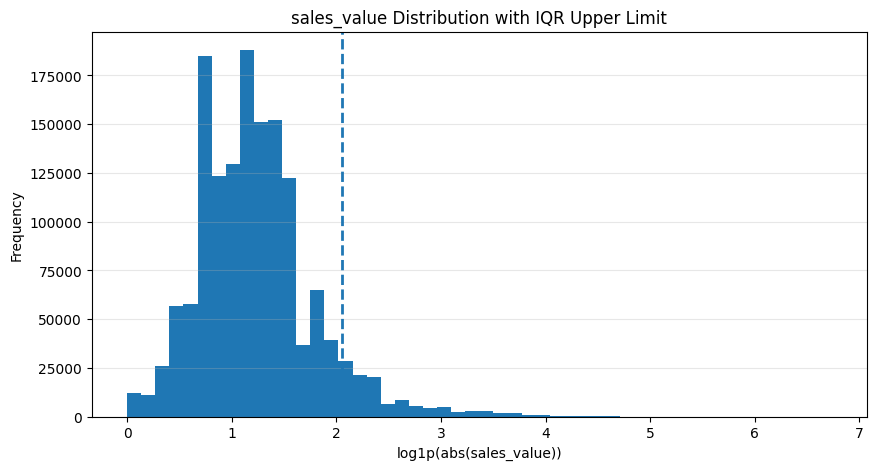

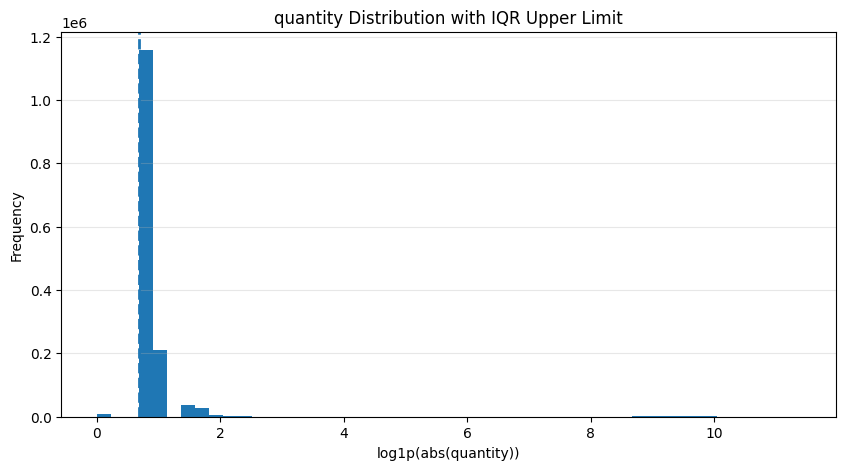

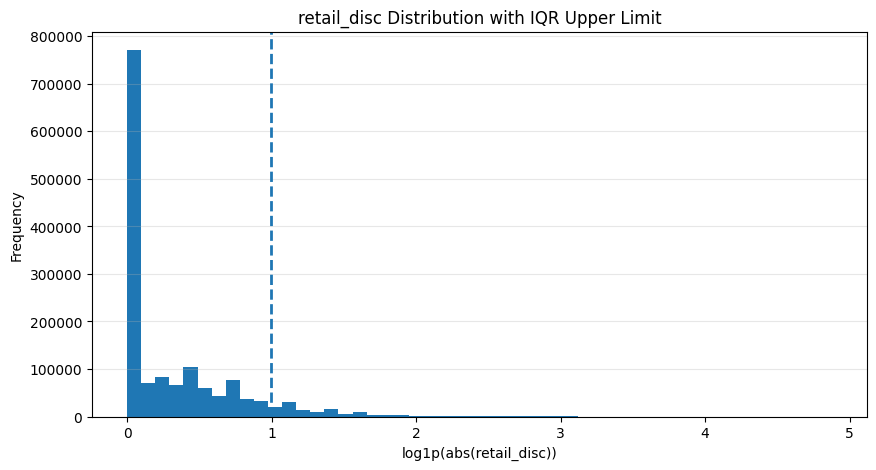

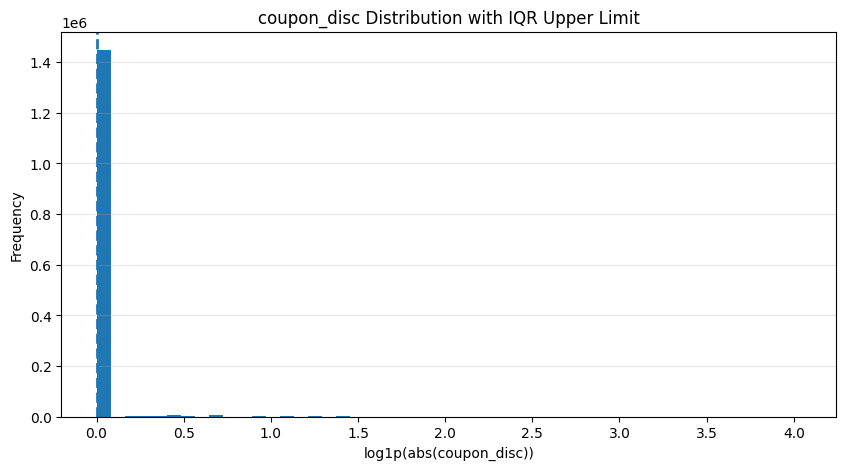

In [21]:
#  Distribution Plots with IQR Limits

if "transactions" in cleaned_tables and not outlier_report_df.empty:
    tx = cleaned_tables["transactions"]

    for col in outlier_columns:
        if col not in tx.columns:
            continue

        report_row = outlier_report_df[outlier_report_df["column"] == col]

        if report_row.empty:
            continue

        upper_limit = report_row["upper_limit"].iloc[0]

        values = pd.to_numeric(tx[col], errors="coerce").dropna()

        # Some columns like discounts may contain negative values.
        # For plotting only, we use absolute values before log transform.
        plot_values = np.log1p(values.abs())

        log_upper_limit = np.log1p(abs(upper_limit))

        plt.figure(figsize=(10, 5))
        plt.hist(plot_values, bins=50)
        plt.axvline(log_upper_limit, linestyle="--", linewidth=2)
        plt.title(f"{col} Distribution with IQR Upper Limit")
        plt.xlabel(f"log1p(abs({col}))")
        plt.ylabel("Frequency")
        plt.grid(axis="y", alpha=0.3)
        plt.show()

,table,column,outlier_count,outlier_percent,lower_limit,upper_limit
0,transactions,sales_value,108975,7.42,-2.01,6.79
1,transactions,quantity,311778,21.22,1.00,1.00
2,transactions,retail_disc,118005,8.03,-1.02,1.70
3,transactions,coupon_disc,21889,1.49,0.00,0.00


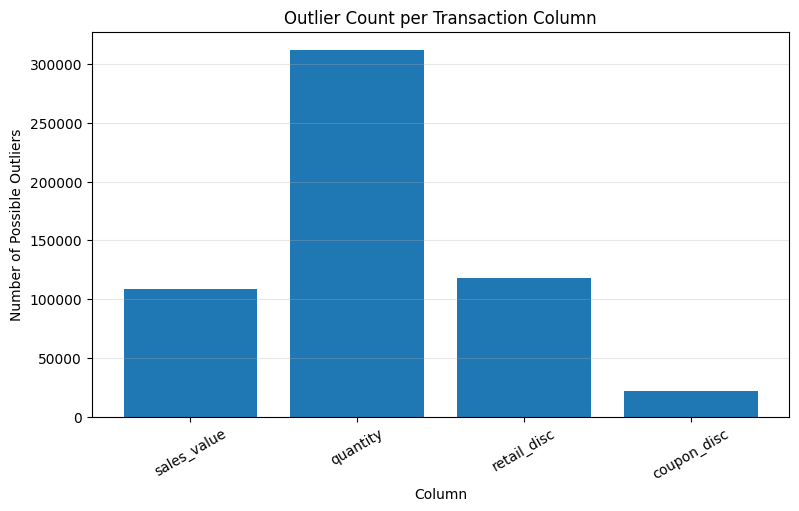

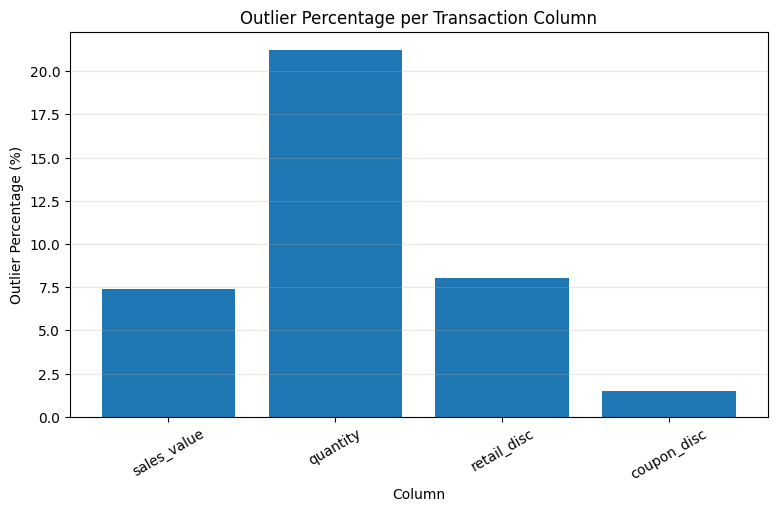

In [20]:
# 20. Outlier Detection Plots

if not outlier_report_df.empty:
    display(outlier_report_df)

    #Outlier Count per Column
    plt.figure(figsize=(9, 5))
    plt.bar(outlier_report_df["column"], outlier_report_df["outlier_count"])
    plt.title("Outlier Count per Transaction Column")
    plt.xlabel("Column")
    plt.ylabel("Number of Possible Outliers")
    plt.xticks(rotation=30)
    plt.grid(axis="y", alpha=0.3)
    plt.show()


    # Outlier Percentage per Column
    plt.figure(figsize=(9, 5))
    plt.bar(outlier_report_df["column"], outlier_report_df["outlier_percent"])
    plt.title("Outlier Percentage per Transaction Column")
    plt.xlabel("Column")
    plt.ylabel("Outlier Percentage (%)")
    plt.xticks(rotation=30)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

else:
    print("No outlier report was generated.")

In [22]:
# Handle Outliers Safely
# We do not delete outliers from transaction data.
# Instead, we create:
# 1. Flag columns: to identify possible outliers.
# 2. Capped columns: useful later for ML or cleaner visualizations.
#
# Original columns remain unchanged.

def add_outlier_flags_and_caps(df, outlier_report_df):
    df = df.copy()

    for _, row in outlier_report_df.iterrows():
        col = row["column"]

        if col not in df.columns:
            continue

        lower_limit = row["lower_limit"]
        upper_limit = row["upper_limit"]

        numeric_values = pd.to_numeric(df[col], errors="coerce")

        flag_col = f"{col}_is_possible_outlier"
        capped_col = f"{col}_capped"

        df[flag_col] = (
            (numeric_values < lower_limit) |
            (numeric_values > upper_limit)
        )

        df[capped_col] = numeric_values.clip(
            lower=lower_limit,
            upper=upper_limit
        )

    return df


if "transactions" in cleaned_tables and not outlier_report_df.empty:
    cleaned_tables["transactions"] = add_outlier_flags_and_caps(
        cleaned_tables["transactions"],
        outlier_report_df
    )

    print("Outlier flags and capped columns were added to transactions.")

    added_columns = [
        col for col in cleaned_tables["transactions"].columns
        if "possible_outlier" in col or col.endswith("_capped")
    ]

    print("Added columns:")
    for col in added_columns:
        print("-", col)

Outlier flags and capped columns were added to transactions.
Added columns:
- sales_value_is_possible_outlier
- sales_value_capped
- quantity_is_possible_outlier
- quantity_capped
- retail_disc_is_possible_outlier
- retail_disc_capped
- coupon_disc_is_possible_outlier
- coupon_disc_capped


In [23]:
#  Business-Aware Outlier Handling
# ============================================================
# IQR is useful, but not perfect for columns with many repeated values.
# For quantity and coupon_disc, we use business-aware handling.

if "transactions" in cleaned_tables:
    tx = cleaned_tables["transactions"]

    # Quantity handling
    # Quantity <= 0 is suspicious.
    # Quantity > 1 is not automatically wrong.
    tx["quantity_is_invalid"] = pd.to_numeric(tx["quantity"], errors="coerce") <= 0

    # Coupon handling
    # coupon_disc > 0 simply means coupon was used.
    # This is rare, but valid.
    tx["coupon_was_used"] = pd.to_numeric(tx["coupon_disc"], errors="coerce") > 0

    # Discount handling
    # retail_disc > 0 means a retail discount exists.
    tx["retail_discount_was_applied"] = pd.to_numeric(tx["retail_disc"], errors="coerce") > 0

    cleaned_tables["transactions"] = tx

    print("Business-aware transaction flags were added:")
    print("- quantity_is_invalid")
    print("- coupon_was_used")
    print("- retail_discount_was_applied")

Business-aware transaction flags were added:
- quantity_is_invalid
- coupon_was_used
- retail_discount_was_applied


## Outlier Detection and Handling Result

We detected possible outliers in the transaction numeric columns using the IQR rule.

The detected columns were:

- `sales_value`
- `quantity`
- `retail_disc`
- `coupon_disc`

### Why we did not delete the outliers

We did not remove these records because the detected values are not confirmed data errors. In retail data, high or unusual values may represent real business behavior, such as:

- large baskets
- bulk purchases
- expensive products
- strong discounts
- coupon-based purchases
- promotion-heavy orders

Removing these rows directly could distort total sales, basket-size analysis, customer segmentation, discount analysis, and market basket mining.

### Important observation

Some columns were marked as outliers because their values are naturally imbalanced.

For example, most rows have `quantity = 1`, so the IQR range becomes very narrow and many valid quantities greater than 1 are marked as outliers.

Also, most rows have `coupon_disc = 0`, so any coupon usage may be detected as an outlier, although it is valid business behavior.

### Handling approach applied

Instead of deleting outliers, we applied a safer data engineering approach:

1. Kept the original values unchanged.
2. Added outlier flag columns to identify possible outlier records.
3. Added capped versions of numeric columns for optional future ML or visualization use.
4. Added business-aware flags:
   - `quantity_is_invalid`
   - `coupon_was_used`
   - `retail_discount_was_applied`

### Final decision

Outliers were reported and flagged, but not removed.

This keeps the cleaned dataset faithful to the original business behavior while still giving the analytics and machine learning layers safer columns to use later if needed.

# Exploratory Data Analysis

The next section explores the business behavior in the dataset.

The objective is not only to produce plots, but also to understand what each plot tells us before building the data warehouse and data mining models.

In [24]:
# 20. EDA Helper Plot Functions

def plot_histogram(series, title, xlabel, file_name, bins=50):
    clean_series = pd.to_numeric(series, errors="coerce").dropna()

    plt.figure(figsize=(10, 5))
    plt.hist(clean_series, bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    save_current_plot(file_name)


def plot_bar(series, title, xlabel, ylabel, file_name, rotation=45):
    plt.figure(figsize=(10, 5))
    plt.bar(series.index.astype(str), series.values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right")
    save_current_plot(file_name)


def plot_line(x, y, title, xlabel, ylabel, file_name):
    plt.figure(figsize=(12, 5))
    plt.plot(x, y)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.3)
    save_current_plot(file_name)

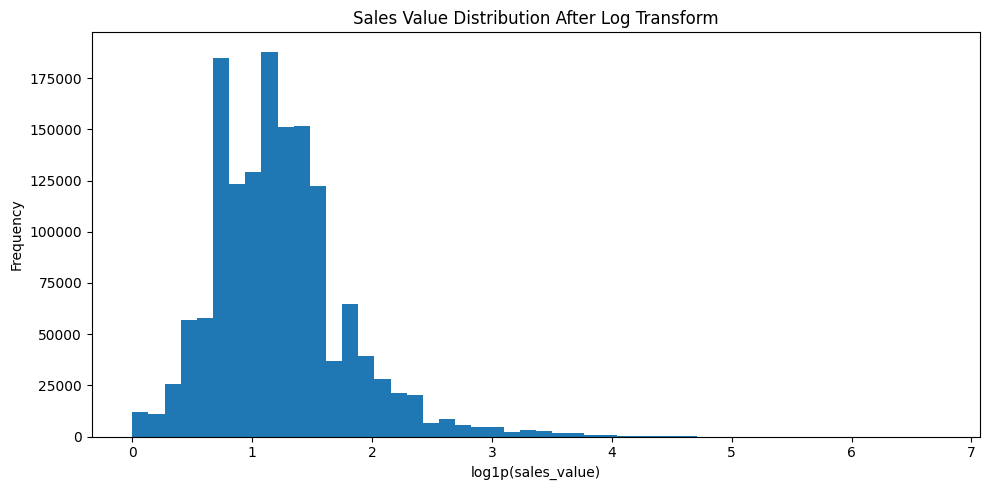

Saved figure: /content/drive/MyDrive/complete_journey_data/preprocessed/figures/sales_value_log_distribution.png


In [25]:
# 21. Sales Value Distribution After Log Transform

if "transactions" in cleaned_tables and "sales_value" in cleaned_tables["transactions"].columns:
    sales_log = np.log1p(pd.to_numeric(cleaned_tables["transactions"]["sales_value"], errors="coerce").clip(lower=0))
    plot_histogram(
        sales_log,
        "Sales Value Distribution After Log Transform",
        "log1p(sales_value)",
        "sales_value_log_distribution.png",
        bins=50
    )

## Sales Value Distribution

The sales distribution is right-skewed.

This means most transaction item rows have small sales values, while a smaller number of rows have higher values.

We used `log1p` only for visualization because it makes the distribution easier to read.

The original `sales_value` is not replaced.

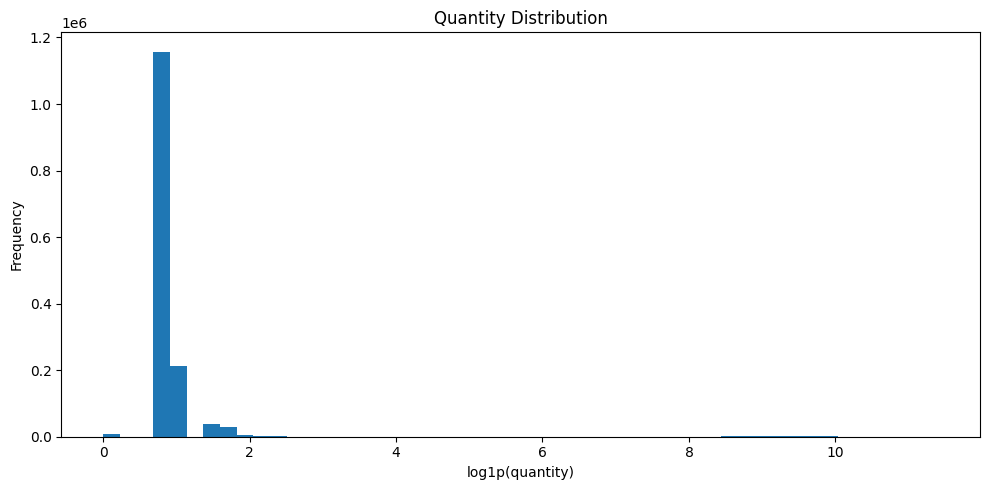

Saved figure: /content/drive/MyDrive/complete_journey_data/preprocessed/figures/quantity_log_distribution.png


In [26]:
# 22. Quantity Distribution After Log Transform

if "transactions" in cleaned_tables and "quantity" in cleaned_tables["transactions"].columns:
    quantity_log = np.log1p(pd.to_numeric(cleaned_tables["transactions"]["quantity"], errors="coerce").clip(lower=0))
    plot_histogram(
        quantity_log,
        "Quantity Distribution",
        "log1p(quantity)",
        "quantity_log_distribution.png",
        bins=50
    )

## Quantity Distribution

Most purchases have low quantity values, while some rows have unusually high quantities.

These high quantities are reported as possible outliers, but they are not removed because they may represent valid bulk purchases or corrections.

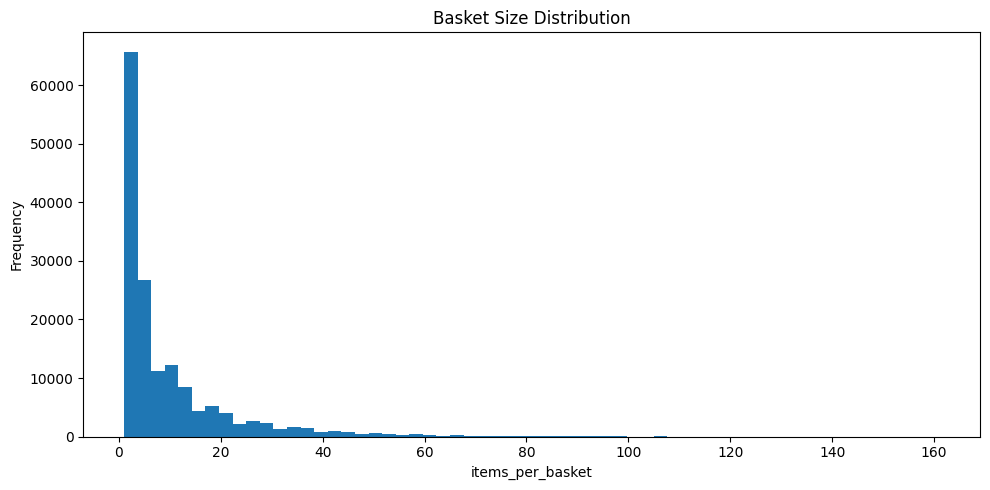

Saved figure: /content/drive/MyDrive/complete_journey_data/preprocessed/figures/basket_size_distribution.png


In [27]:
# 23. Basket Size Distribution

if "transactions" in cleaned_tables and "basket_id" in cleaned_tables["transactions"].columns:
    basket_size = cleaned_tables["transactions"].groupby("basket_id").size()

    plot_histogram(
        basket_size,
        "Basket Size Distribution",
        "items_per_basket",
        "basket_size_distribution.png",
        bins=60
    )

    basket_size.describe()

## Basket Size Distribution

The basket size plot shows that most baskets contain a small number of items.

A smaller number of baskets contain many items. These larger baskets are useful for market basket analysis because they contain more product combinations.

In [28]:
# 24. Total Spend per Household Distribution

if "transactions" in cleaned_tables and {"household_key", "sales_value"}.issubset(cleaned_tables["transactions"].columns):
    spend_per_household = (
        cleaned_tables["transactions"]
        .groupby("household_key")["sales_value"]
        .sum()
    )

    spend_log = np.log1p(spend_per_household.clip(lower=0))

    plot_histogram(
        spend_log,
        "Total Spend per Household Distribution",
        "log1p(total_spend)",
        "total_spend_per_household_distribution.png",
        bins=50
    )

    spend_per_household.describe()

## Household Spending Distribution

The total spend per household shows variation between customers.

This supports the customer segmentation part of the project because households do not all behave the same way.

Some customers are low spenders, while others are high-value customers.

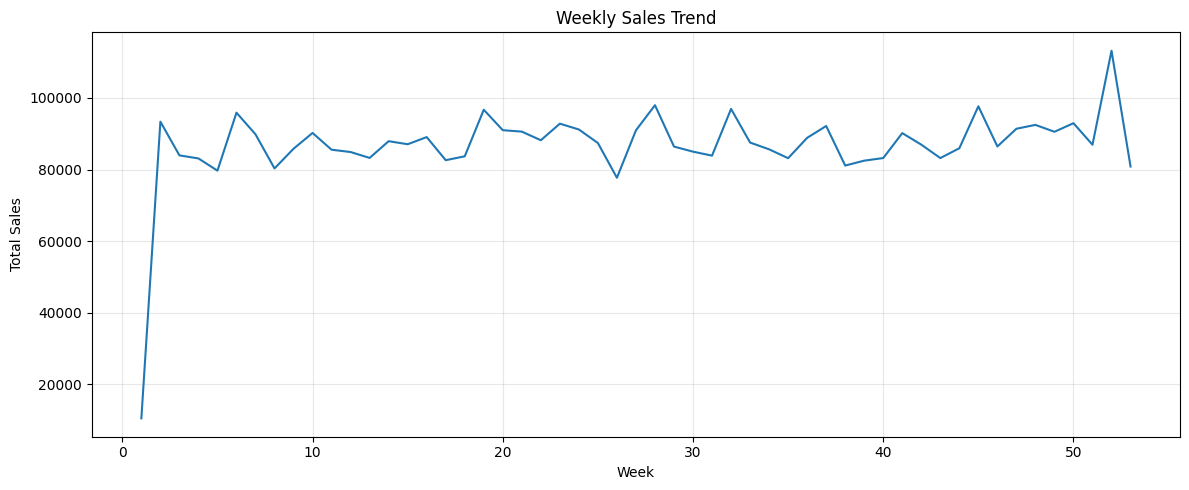

Saved figure: /content/drive/MyDrive/complete_journey_data/preprocessed/figures/weekly_sales_trend.png


In [29]:
# 25. Weekly Sales Trend
if "transactions" in cleaned_tables and {"week", "sales_value"}.issubset(cleaned_tables["transactions"].columns):
    weekly_sales = (
        cleaned_tables["transactions"]
        .groupby("week")["sales_value"]
        .sum()
        .sort_index()
    )

    plot_line(
        weekly_sales.index,
        weekly_sales.values,
        "Weekly Sales Trend",
        "Week",
        "Total Sales",
        "weekly_sales_trend.png"
    )

    weekly_sales.head()

## Weekly Sales Trend

The weekly sales trend shows sales movement across the year.

This is important for:

- seasonality analysis
- campaign analysis
- holiday impact analysis
- weekly Power BI dashboard visuals

The first week may look lower because the dataset can start mid-week or have partial coverage.

In [30]:
# 26. Join Transactions with Products for Product EDA

transaction_products = None

if "transactions" in cleaned_tables and "products" in cleaned_tables:
    if "product_id" in cleaned_tables["transactions"].columns and "product_id" in cleaned_tables["products"].columns:
        transaction_products = cleaned_tables["transactions"].merge(
            cleaned_tables["products"],
            on="product_id",
            how="left"
        )

        print("Transaction-product joined table created.")
        print(transaction_products.shape)
    else:
        print("product_id column was not found in one of the tables.")

Transaction-product joined table created.
(1469307, 30)


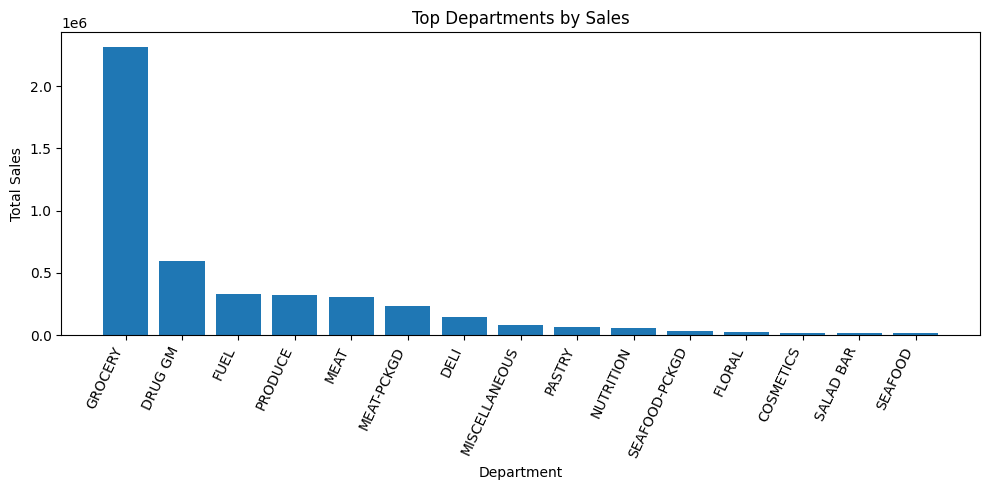

Saved figure: /content/drive/MyDrive/complete_journey_data/preprocessed/figures/top_departments_by_sales.png


In [31]:
# 27. Top Departments by Sales

if transaction_products is not None and {"department", "sales_value"}.issubset(transaction_products.columns):
    top_departments = (
        transaction_products
        .groupby("department")["sales_value"]
        .sum()
        .sort_values(ascending=False)
        .head(15)
    )

    plot_bar(
        top_departments,
        "Top Departments by Sales",
        "Department",
        "Total Sales",
        "top_departments_by_sales.png",
        rotation=65
    )

    top_departments

## Top Departments by Sales

The sales are concentrated in a few departments.

In the observed output, `GROCERY` was the strongest department by sales.

This helps us identify which departments should receive more attention in the dashboard, market basket analysis, and recommendation engine.

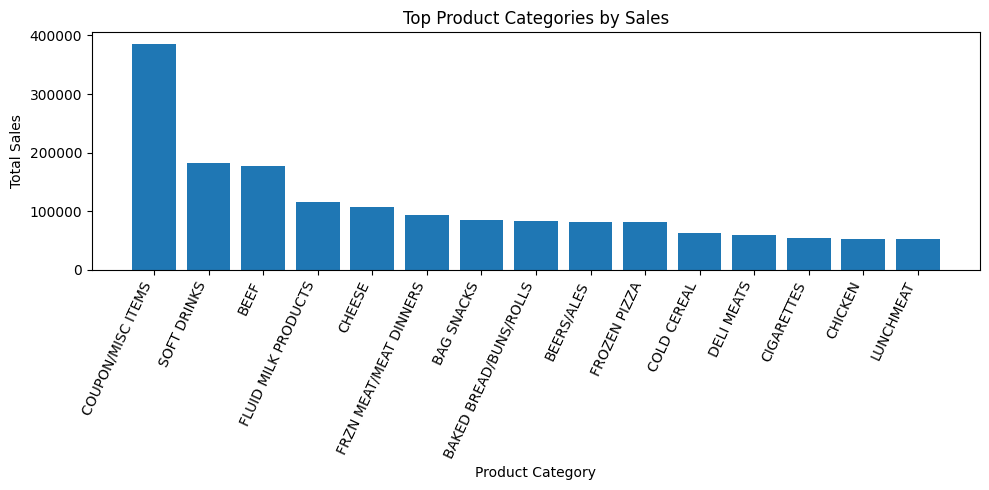

Saved figure: /content/drive/MyDrive/complete_journey_data/preprocessed/figures/top_product_categories_by_sales.png


In [32]:
# 28. Top Product Categories by Sales

if transaction_products is not None and {"product_category", "sales_value"}.issubset(transaction_products.columns):
    top_categories = (
        transaction_products
        .groupby("product_category")["sales_value"]
        .sum()
        .sort_values(ascending=False)
        .head(15)
    )

    plot_bar(
        top_categories,
        "Top Product Categories by Sales",
        "Product Category",
        "Total Sales",
        "top_product_categories_by_sales.png",
        rotation=65
    )

    top_categories

## Top Product Categories by Sales

The product category chart shows which categories generate the highest sales.

This result will help later when creating:

- product dimension analytics
- category-level dashboards
- association rule interpretation
- recommendation examples

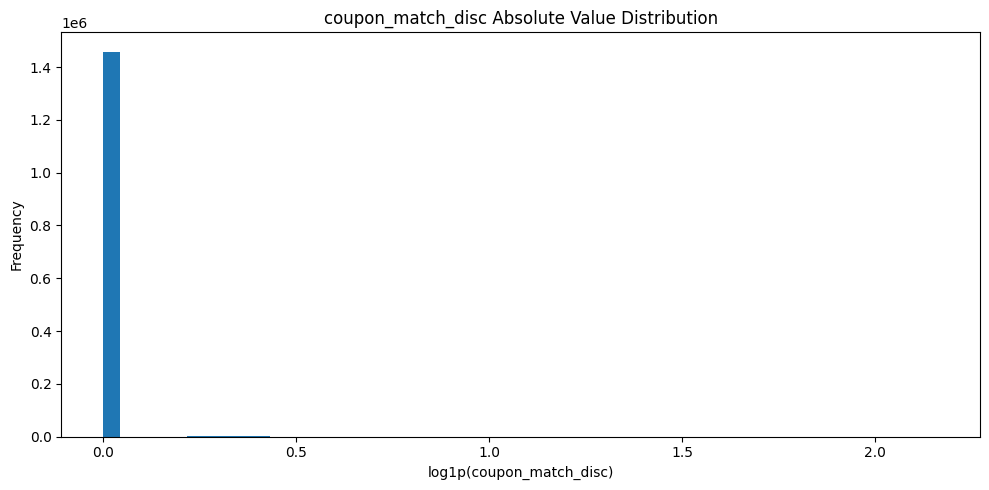

Saved figure: /content/drive/MyDrive/complete_journey_data/preprocessed/figures/coupon_match_discount_distribution.png


In [33]:
# 29. Coupon Discount Distribution

if "transactions" in cleaned_tables and "coupon_match_disc" in cleaned_tables["transactions"].columns:
    coupon_match_log = np.log1p(
        pd.to_numeric(cleaned_tables["transactions"]["coupon_match_disc"], errors="coerce")
        .abs()
        .clip(lower=0)
    )

    plot_histogram(
        coupon_match_log,
        "coupon_match_disc Absolute Value Distribution",
        "log1p(coupon_match_disc)",
        "coupon_match_discount_distribution.png",
        bins=50
    )

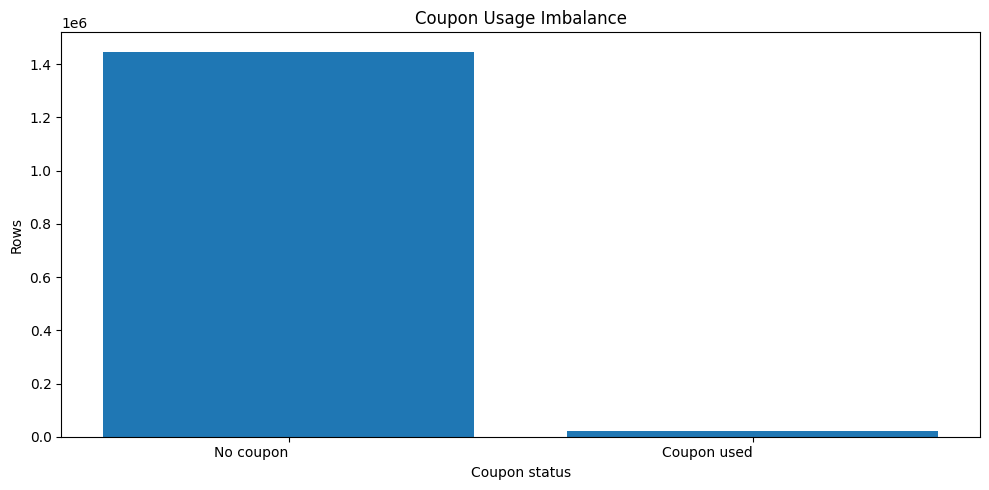

Saved figure: /content/drive/MyDrive/complete_journey_data/preprocessed/figures/coupon_usage_imbalance.png


In [34]:
# 30. Coupon Usage Imbalance Plot

if "transactions" in cleaned_tables and "coupon_disc" in cleaned_tables["transactions"].columns:
    tx = cleaned_tables["transactions"].copy()
    tx["coupon_status"] = np.where(tx["coupon_disc"].abs() > 0, "Coupon used", "No coupon")

    coupon_counts = tx["coupon_status"].value_counts()

    plot_bar(
        coupon_counts,
        "Coupon Usage Imbalance",
        "Coupon status",
        "Rows",
        "coupon_usage_imbalance.png",
        rotation=0
    )

    coupon_counts

## Coupon Usage Result

Coupon usage is highly imbalanced.

Most rows have no coupon discount, while a small percentage has coupon usage.

This is not an error. It is a real business pattern.

We report the imbalance, but we do not oversample because oversampling would damage association rule metrics and business distributions.

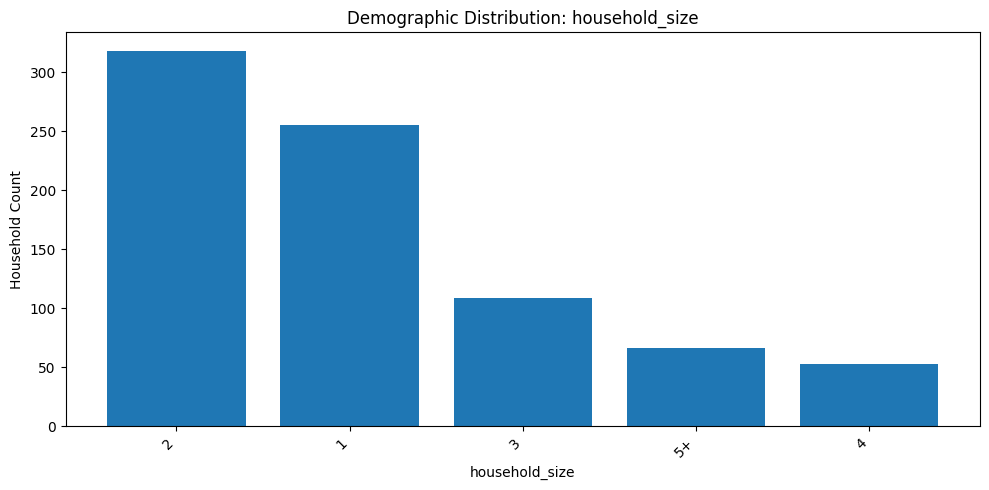

Saved figure: /content/drive/MyDrive/complete_journey_data/preprocessed/figures/demographic_distribution_household_size.png


,count
household_size,
2,318
1,255
3,109
5+,66
4,53


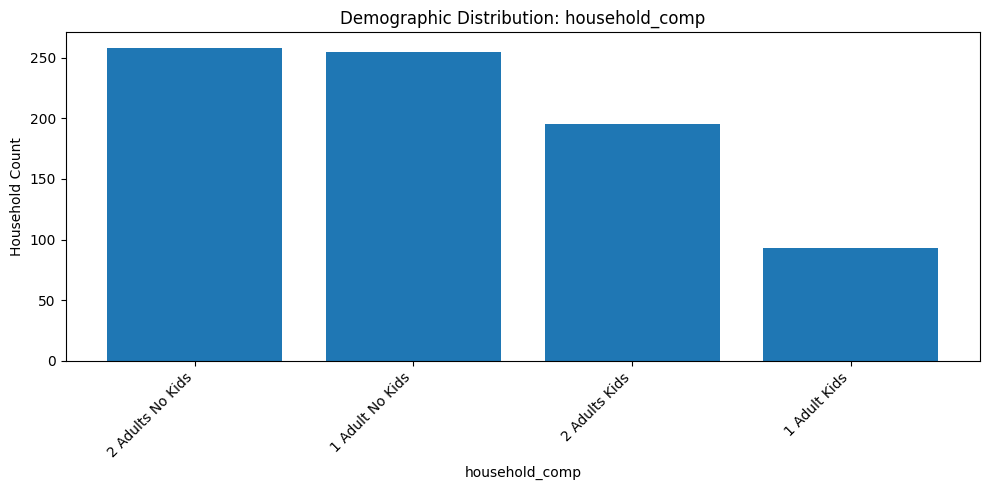

Saved figure: /content/drive/MyDrive/complete_journey_data/preprocessed/figures/demographic_distribution_household_comp.png


,count
household_comp,
2 Adults No Kids,258
1 Adult No Kids,255
2 Adults Kids,195
1 Adult Kids,93


In [35]:
# 31. Demographic Distribution Plots

if "demographics" in cleaned_tables:
    demo = cleaned_tables["demographics"]

    for col in ["household_size", "household_comp"]:
        if col in demo.columns:
            counts = demo[col].value_counts()

            plot_bar(
                counts,
                f"Demographic Distribution: {col}",
                col,
                "Household Count",
                f"demographic_distribution_{col}.png",
                rotation=45
            )

            display(counts)

## Demographic Distribution

The demographic plots show the structure of the households.

For example:

- household size distribution
- household composition distribution

These fields will support customer segmentation and business interpretation.

In [37]:
# 33. Profile Cleaned Tables

clean_profile_records = []

for table_name, df in cleaned_tables.items():
    duplicate_rows = int(df.duplicated().sum())
    missing_cells = int(df.isna().sum().sum())
    total_cells = int(df.shape[0] * df.shape[1])
    missing_percent = (missing_cells / total_cells * 100) if total_cells > 0 else 0
    memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

    clean_profile_records.append({
        "table": f"{table_name}_clean",
        "rows": df.shape[0],
        "columns": df.shape[1],
        "duplicate_rows": duplicate_rows,
        "missing_cells": missing_cells,
        "missing_percent": round(missing_percent, 2),
        "memory_mb": round(memory_mb, 2)
    })

clean_profile_df = pd.DataFrame(clean_profile_records)

all_profile_df = pd.concat([raw_profile_df, clean_profile_df], ignore_index=True)
all_profile_df.sort_values(["table"])

,table,rows,columns,duplicate_rows,missing_cells,missing_percent,memory_mb
11,campaign_descriptions_clean,27,4,0,0,0.00,0.00
14,campaigns_clean,6589,2,0,0,0.00,0.10
15,coupon_redemptions_clean,2102,4,0,0,0.00,0.17
13,coupons_clean,111332,3,0,0,0.00,3.40
12,demographics_clean,801,8,0,0,0.00,0.30
10,products_clean,92331,7,0,0,0.00,27.75
9,promotions_clean,20940529,5,0,0,0.00,2476.34
3,raw_campaign_descriptions,27,4,0,0,0.00,0.00
6,raw_campaigns,6589,2,0,0,0.00,0.10
7,raw_coupon_redemptions,2102,4,0,0,0.00,0.17


## Final Cleaned Data Result

After cleaning:

- `coupons_clean` has no duplicate rows.
- `products_clean` has no missing categorical values in the handled columns.
- `demographics_clean` has no missing demographic values in the handled columns.
- `transactions_clean` keeps all transaction rows and adds parsed date fields.
- Outliers, invalid quantities, and referential integrity problems are reported but not deleted.

This approach is suitable for a data warehouse project because we preserve business facts and document data quality problems clearly.

In [38]:
# 34. Build Final Reports

data_quality_issues_df = pd.DataFrame(data_quality_issues)
cleaning_actions_df = pd.DataFrame(cleaning_actions)

if not data_quality_issues_df.empty:
    issue_summary_df = (
        data_quality_issues_df
        .groupby(["severity", "issue_type"], as_index=False)
        .agg(
            issue_count=("issue_type", "count"),
            affected_rows=("affected_rows", "sum")
        )
        .sort_values(["severity", "affected_rows"], ascending=[True, False])
    )
else:
    issue_summary_df = pd.DataFrame(columns=["severity", "issue_type", "issue_count", "affected_rows"])

display(data_quality_issues_df)
display(cleaning_actions_df)
display(issue_summary_df)

,run_time,table,issue_type,severity,message,affected_rows,action
0,2026-05-19 16:37:31,coupons,exact_duplicate_rows,warning,Exact duplicate rows were found.,4872,Removed exact duplicate rows.
1,2026-05-19 16:37:40,products,missing_categorical_value,info,Missing values found in 'product_category'.,540,Filled with Unknown.
2,2026-05-19 16:37:40,products,missing_categorical_value,info,Missing values found in 'product_type'.,528,Filled with Unknown.
3,2026-05-19 16:37:40,products,missing_categorical_value,info,Missing values found in 'package_size'.,30586,Filled with Unknown.
4,2026-05-19 16:37:50,demographics,missing_demographic_value,info,Missing values found in 'home_ownership'.,233,Filled with Unknown.
5,2026-05-19 16:37:50,demographics,missing_demographic_value,info,Missing values found in 'marital_status'.,137,Filled with Unknown.
6,2026-05-19 16:38:21,transactions,invalid_quantity,warning,Quantity less than or equal to zero was found.,8869,"Kept rows, but flagged for analysis."
7,2026-05-19 16:38:49,transactions,referential_integrity,error,Some product_id values in transactions were no...,4836,Kept rows and reported issue. ETL may map miss...
8,2026-05-19 16:39:26,transactions,class_imbalance,info,Coupon usage appears rare: 1.49% of rows.,21889,Reported only. No oversampling applied in prep...
9,2026-05-19 16:40:03,transactions,possible_outliers,info,"Column sales_value has 108,975 possible outlie...",108975,Reported only. Outliers were not removed autom...


,table,problem,action_taken,reason
0,coupons,Exact duplicate rows,Removed duplicates,Exact duplicates add fake volume and bias anal...
1,products,Missing product_category,Filled with Unknown,Unknown is safer than dropping useful products.
2,products,Missing product_type,Filled with Unknown,Unknown is safer than dropping useful products.
3,products,Missing package_size,Filled with Unknown,Unknown is safer than dropping useful products.
4,demographics,Missing home_ownership,Filled with Unknown,Dropping customers would bias segmentation.
5,demographics,Missing marital_status,Filled with Unknown,Dropping customers would bias segmentation.
6,transactions,Quantity <= 0,Kept and flagged,These rows may represent returns or corrections.
7,transactions,Missing parent key in products,Kept and reported,Fact records should not be deleted before busi...
8,transactions,Coupon usage imbalance,Reported without oversampling,ETL data must preserve real business distribut...


,severity,issue_type,issue_count,affected_rows
0,error,referential_integrity,1,4836
4,info,possible_outliers,4,560647
2,info,missing_categorical_value,3,31654
1,info,class_imbalance,1,21889
3,info,missing_demographic_value,2,370
6,warning,invalid_quantity,1,8869
5,warning,exact_duplicate_rows,1,4872


## Data Quality Report Summary

The main issues reported were:

1. Missing categorical product values.
2. Missing demographic values.
3. Exact duplicate rows in coupons.
4. Invalid quantity rows in transactions.
5. Referential integrity gaps between transactions and lookup tables.
6. Coupon usage imbalance.
7. Possible numeric outliers.

The notebook solved only the safe problems directly.

Problems that need business validation were reported and preserved.

In [40]:
# 36. Save Cleaned Tables and Reports

# Save cleaned main tables
for table_name, df in cleaned_tables.items():
    output_path = PREPROCESSED_DIR / f"{table_name}_clean.csv"
    df.to_csv(output_path, index=False)
    print(f"Saved cleaned table: {output_path}")

# Save reports
raw_profile_df.to_csv(REPORTS_DIR / "raw_table_profile.csv", index=False)
clean_profile_df.to_csv(REPORTS_DIR / "clean_table_profile.csv", index=False)
all_profile_df.to_csv(REPORTS_DIR / "raw_and_clean_table_profile.csv", index=False)
missing_report_df.to_csv(REPORTS_DIR / "missing_value_report.csv", index=False)
outlier_report_df.to_csv(REPORTS_DIR / "outlier_report.csv", index=False)
data_quality_issues_df.to_csv(REPORTS_DIR / "data_quality_issues.csv", index=False)
cleaning_actions_df.to_csv(REPORTS_DIR / "cleaning_actions_report.csv", index=False)
issue_summary_df.to_csv(REPORTS_DIR / "data_quality_issue_summary.csv", index=False)

print("\nAll cleaned tables and reports were saved successfully.")

Saved cleaned table: /content/drive/MyDrive/complete_journey_data/preprocessed/transactions_clean.csv
Saved cleaned table: /content/drive/MyDrive/complete_journey_data/preprocessed/promotions_clean.csv
Saved cleaned table: /content/drive/MyDrive/complete_journey_data/preprocessed/products_clean.csv
Saved cleaned table: /content/drive/MyDrive/complete_journey_data/preprocessed/campaign_descriptions_clean.csv
Saved cleaned table: /content/drive/MyDrive/complete_journey_data/preprocessed/demographics_clean.csv
Saved cleaned table: /content/drive/MyDrive/complete_journey_data/preprocessed/coupons_clean.csv
Saved cleaned table: /content/drive/MyDrive/complete_journey_data/preprocessed/campaigns_clean.csv
Saved cleaned table: /content/drive/MyDrive/complete_journey_data/preprocessed/coupon_redemptions_clean.csv

All cleaned tables and reports were saved successfully.


# Derived Files for Data Mining

The ETL layer will use the cleaned main tables.

For the data mining layer, we also create two optional helper files:

1. `basket_items_for_mba.csv`  
   Used for market basket analysis.

2. `customer_rfm_base.csv`  
   Used for customer segmentation.

These files are not replacements for the warehouse. They are analysis-ready outputs.

In [41]:
# 37. Create Basket Items File for Market Basket Analysis

if transaction_products is not None:
    basket_cols = []

    for col in ["basket_id", "product_id", "department", "product_category", "product_type"]:
        if col in transaction_products.columns:
            basket_cols.append(col)

    basket_items_for_mba = transaction_products[basket_cols].drop_duplicates()

    output_path = PREPROCESSED_DIR / "basket_items_for_mba.csv"
    basket_items_for_mba.to_csv(output_path, index=False)

    print(f"Saved basket items file: {output_path}")
    display(basket_items_for_mba.head())
else:
    print("transaction_products was not created, so basket_items_for_mba.csv was skipped.")

Saved basket items file: /content/drive/MyDrive/complete_journey_data/preprocessed/basket_items_for_mba.csv


,basket_id,product_id,department,product_category,product_type
0,3.119857e+10,1095275.0,PASTRY,ROLLS,ROLLS: BAGELS
1,3.119857e+10,9878513.0,GROCERY,FACIAL TISS/DNR NAPKIN,FACIAL TISSUE & PAPER HANDKE
2,3.119866e+10,1041453.0,GROCERY,BAG SNACKS,POTATO CHIPS
3,3.119871e+10,1020156.0,GROCERY,REFRGRATD DOUGH PRODUCTS,REFRIGERATED BAGELS
4,3.119871e+10,1053875.0,GROCERY,SEAFOOD - SHELF STABLE,TUNA


In [42]:
# 38. Create Customer RFM Base File

if "transactions" in cleaned_tables:
    tx = cleaned_tables["transactions"]

    required_cols = {"household_key", "basket_id", "sales_value", "transaction_datetime"}

    if required_cols.issubset(tx.columns):
        max_date = tx["transaction_datetime"].max()

        customer_rfm_base = (
            tx.groupby("household_key")
            .agg(
                last_purchase_date=("transaction_datetime", "max"),
                frequency=("basket_id", "nunique"),
                monetary=("sales_value", "sum")
            )
            .reset_index()
        )

        customer_rfm_base["recency_days"] = (
            max_date - customer_rfm_base["last_purchase_date"]
        ).dt.days

        output_path = PREPROCESSED_DIR / "customer_rfm_base.csv"
        customer_rfm_base.to_csv(output_path, index=False)

        print(f"Saved customer RFM base file: {output_path}")
        display(customer_rfm_base.head())
    else:
        print("Required columns for RFM were not found.")

Required columns for RFM were not found.


| Area                  | Table                           | Column / Field           | Finding / Issue                                                                           | Severity |                     Affected Rows / Values | Handling Applied                                                                                                                                           | Reason                                                                                                                                                                  |
| --------------------- | ------------------------------- | ------------------------ | ----------------------------------------------------------------------------------------- | -------- | -----------------------------------------: | ---------------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| File loading          | All raw files                   | File names               | File names are already known and fixed.                                                   | Info     |                                        N/A | Removed dynamic file search logic using `FILE_CANDIDATES` and `find_file()`.                                                                               | The notebook became simpler and more stable because we load exact known files directly.                                                                                 |
| Column naming         | All raw files                   | All columns              | Original column names are already readable and compatible with the dataset.               | Info     |                                        N/A | Removed `standardize_column_names()`. Kept column names as they are in the source files.                                                                   | This avoids unexpected changes in downstream cells and keeps the notebook aligned with the original dataset documentation.                                              |
| Raw profiling         | `promotions`                    | All columns              | Very large table with `20,940,529` rows and around `2476.34 MB` memory usage.             | Info     |                            20,940,529 rows | Kept table unchanged. Reported high memory usage.                                                                                                          | This is not a data error. It is an engineering issue. Later ETL should load this table in chunks.                                                                       |
| Raw profiling         | `transactions`                  | All columns              | Large fact-like table with `1,469,307` rows and no missing values.                        | Info     |                             1,469,307 rows | Kept table as the main transaction source.                                                                                                                 | Transactions are the central fact table for sales, baskets, RFM, and market basket analysis.                                                                            |
| Duplicates            | `coupons`                       | Full row duplicate       | Exact duplicate rows were found.                                                          | Warning  |                       4,872 duplicate rows | Removed duplicates using `drop_duplicates()`. Rows reduced from `116,204` to `111,332`.                                                                    | Exact duplicates can inflate joins and bias coupon analysis.                                                                                                            |
| Missing values        | `products`                      | `package_size`           | Missing product package size values.                                                      | Info     |            30,586 missing values, `33.13%` | Filled missing values with `"Unknown"`.                                                                                                                    | Package size is descriptive metadata. Dropping products would break product joins and reduce transaction coverage.                                                      |
| Missing values        | `products`                      | `product_category`       | Missing product category values.                                                          | Info     |                540 missing values, `0.58%` | Filled missing values with `"Unknown"`.                                                                                                                    | Product records should be preserved for product dimension and basket analysis.                                                                                          |
| Missing values        | `products`                      | `product_type`           | Missing product type values.                                                              | Info     |                528 missing values, `0.57%` | Filled missing values with `"Unknown"`.                                                                                                                    | Product type is categorical metadata, so imputation with `"Unknown"` is safer than deletion.                                                                            |
| Missing values        | `demographics`                  | `home_ownership`         | Missing household home ownership values.                                                  | Info     |               233 missing values, `29.09%` | Filled missing values with `"Unknown"`.                                                                                                                    | Dropping households would bias customer segmentation and demographic analysis.                                                                                          |
| Missing values        | `demographics`                  | `marital_status`         | Missing marital status values.                                                            | Info     |               137 missing values, `17.10%` | Filled missing values with `"Unknown"`.                                                                                                                    | Missing demographic fields are not enough reason to remove customer records.                                                                                            |
| Invalid values        | `transactions`                  | `quantity`               | Some rows have quantity less than or equal to zero.                                       | Warning  |                                 8,869 rows | Kept rows and added a business-aware flag: `quantity_is_invalid`.                                                                                          | These may represent returns, corrections, or special transaction cases. They should not be deleted blindly.                                                             |
| Referential integrity | `transactions` → `products`     | `product_id`             | Some transaction rows have product IDs not found in the product table.                    | Error    |                                 4,836 rows | Kept rows and reported the issue. Recommended mapping them to an `"Unknown Product"` row during ETL.                                                       | Fact records should not be deleted before business validation. Removing them would reduce sales accuracy.                                                               |
| Referential integrity | `transactions` → `demographics` | `household_key`          | Many transaction rows have household keys not found in demographics.                      | Warning  |                               640,457 rows | Kept rows and reported the issue. Recommended mapping them to an `"Unknown Household"` or keeping demographic attributes as null/unknown in the warehouse. | Demographics table covers only a subset of households. This is expected and should not remove valid transactions.                                                       |
| Class imbalance       | `transactions`                  | `coupon_disc`            | Coupon usage is rare. Only rows with coupon discount greater than zero show coupon usage. | Info     |                       21,889 rows, `1.49%` | Added `coupon_was_used` flag. No oversampling applied.                                                                                                     | This is real business distribution. Oversampling would distort support, confidence, basket frequency, and sales analysis.                                               |
| Discount indicator    | `transactions`                  | `retail_disc`            | Retail discounts are not applied to all rows.                                             | Info     | 118,005 possible high discount rows by IQR | Added `retail_discount_was_applied` flag. Kept values unchanged.                                                                                           | Discount behavior is useful for promotion and campaign analysis.                                                                                                        |
| Outliers              | `transactions`                  | `sales_value`            | IQR detected high/low possible outliers.                                                  | Info     |                      108,975 rows, `7.42%` | Kept original values. Added `sales_value_is_possible_outlier` and `sales_value_capped`.                                                                    | High sales may represent valid expensive products, large baskets, or bulk purchases.                                                                                    |
| Outliers              | `transactions`                  | `quantity`               | IQR detected many possible outliers.                                                      | Info     |                     311,778 rows, `21.22%` | Kept original values. Added `quantity_is_possible_outlier`, `quantity_capped`, and `quantity_is_invalid`.                                                  | Most rows have `quantity = 1`, so IQR becomes too strict. Quantity above 1 is usually normal.                                                                           |
| Outliers              | `transactions`                  | `retail_disc`            | IQR detected large discount values.                                                       | Info     |                      118,005 rows, `8.03%` | Kept original values. Added `retail_disc_is_possible_outlier`, `retail_disc_capped`, and `retail_discount_was_applied`.                                    | Large discounts may be valid due to promotions, campaigns, or clearance offers.                                                                                         |
| Outliers              | `transactions`                  | `coupon_disc`            | IQR detected coupon usage as outlier because most rows have `coupon_disc = 0`.            | Info     |                       21,889 rows, `1.49%` | Kept original values. Added `coupon_disc_is_possible_outlier`, `coupon_disc_capped`, and `coupon_was_used`.                                                | Coupon usage is rare but valid. It should be analyzed, not removed.                                                                                                     |
| Clean profiling       | `products_clean`                | All columns              | Missing values became zero after cleaning.                                                | Info     |                                92,331 rows | Validated clean profile.                                                                                                                                   | Confirms missing product metadata was handled successfully.                                                                                                             |
| Clean profiling       | `demographics_clean`            | All columns              | Missing values became zero after cleaning.                                                | Info     |                                   801 rows | Validated clean profile.                                                                                                                                   | Confirms missing demographic values were handled successfully.                                                                                                          |
| Clean profiling       | `coupons_clean`                 | All columns              | Duplicate rows became zero after cleaning.                                                | Info     |                               111,332 rows | Validated clean profile.                                                                                                                                   | Confirms duplicate coupon records were removed successfully.                                                                                                            |
| Clean profiling       | `transactions_clean`            | Derived date columns     | Added `transaction_datetime` and `transaction_date`.                                      | Info     |                             1,469,307 rows | Converted `transaction_timestamp` to datetime and extracted date.                                                                                          | These fields are needed for date dimension, trend analysis, holiday analysis, and time-based dashboards.                                                                |
| Oversampling          | `transactions`                  | Coupon usage / imbalance | Dataset has natural imbalance in coupon usage.                                            | Info     |                     Coupon usage = `1.49%` | No oversampling applied.                                                                                                                                   | The project is focused on DWH, EDA, association rules, segmentation, and recommendation. Oversampling is not suitable here because it would fake transaction frequency. |
| Export                | Cleaned tables                  | All main tables          | Cleaned tables are ready for ETL.                                                         | Info     |                           Main tables only | Exported cleaned versions of main tables. Excluded sample/helper files from the main cleaning pipeline.                                                    | ETL scripts should read clean full tables, not sample or documentation files.                                                                                           |


| Table                   |   Raw Rows | Clean Rows | Main Issue Found                                                    | Cleaning Result                                                                         |
| ----------------------- | ---------: | ---------: | ------------------------------------------------------------------- | --------------------------------------------------------------------------------------- |
| `transactions`          |  1,469,307 |  1,469,307 | Invalid quantities, referential integrity issues, possible outliers | Rows kept, issues flagged, datetime/date fields added, outlier and business flags added |
| `products`              |     92,331 |     92,331 | Missing `package_size`, `product_category`, and `product_type`      | Missing values filled with `"Unknown"`                                                  |
| `demographics`          |        801 |        801 | Missing `home_ownership` and `marital_status`                       | Missing values filled with `"Unknown"`                                                  |
| `coupons`               |    116,204 |    111,332 | Exact duplicate rows                                                | 4,872 duplicates removed                                                                |
| `campaigns`             |      6,589 |      6,589 | No major issue                                                      | Kept unchanged                                                                          |
| `campaign_descriptions` |         27 |         27 | No major issue                                                      | Kept unchanged                                                                          |
| `coupon_redemptions`    |      2,102 |      2,102 | No major issue                                                      | Kept unchanged                                                                          |
| `promotions`            | 20,940,529 | 20,940,529 | Very large table                                                    | Kept unchanged, recommended chunk-based ETL loading                                     |
| `holidays`              |          9 |          9 | No major issue                                                      | Kept unchanged                                                                          |


| Severity | Issue Type                                           | Count |            Affected Rows | Handling                                                               |
| -------- | ---------------------------------------------------- | ----: | -----------------------: | ---------------------------------------------------------------------- |
| Error    | Referential integrity: missing product reference     |     1 |                    4,836 | Kept and reported. Recommended mapping to unknown product during ETL.  |
| Warning  | Referential integrity: missing demographic reference |     1 |                  640,457 | Kept and reported. Demographics table is partial, so this is expected. |
| Warning  | Exact duplicate rows                                 |     1 |                    4,872 | Removed exact duplicates from coupons.                                 |
| Warning  | Invalid quantity                                     |     1 |                    8,869 | Kept and flagged using `quantity_is_invalid`.                          |
| Info     | Missing categorical product values                   |     3 |                   31,654 | Filled with `"Unknown"`.                                               |
| Info     | Missing demographic values                           |     2 |                      370 | Filled with `"Unknown"`.                                               |
| Info     | Possible outliers                                    |     4 | 560,647 total detections | Kept original values, added outlier flags and capped columns.          |
| Info     | Coupon usage imbalance                               |     1 |                   21,889 | Reported only, added `coupon_was_used`, no oversampling.               |
| Info     | High memory usage                                    |     1 |               20,940,529 | Kept data, recommended chunk-based loading in ETL.                     |


| Decision                        | Applied?                  | Explanation                                                                                                  |
| ------------------------------- | ------------------------- | ------------------------------------------------------------------------------------------------------------ |
| Remove exact duplicates         | Yes, only for `coupons`   | Duplicate coupon mappings can bias coupon analysis.                                                          |
| Drop rows with missing values   | No                        | Missing values were in descriptive categorical columns, so dropping rows would lose useful business records. |
| Fill missing categorical values | Yes                       | Filled missing product and demographic values with `"Unknown"`.                                              |
| Delete outliers                 | No                        | Outliers may represent real retail behavior.                                                                 |
| Add outlier flags               | Yes                       | Helps identify unusual records without deleting them.                                                        |
| Add capped columns              | Yes                       | Useful later for ML models or visualizations.                                                                |
| Handle invalid quantity         | Flagged, not removed      | Quantity `<= 0` may represent returns or corrections.                                                        |
| Handle rare coupon usage        | Reported, not oversampled | Coupon usage imbalance is real business behavior.                                                            |
| Oversampling                    | No                        | Oversampling would distort transaction patterns and association rule metrics.                                |
| Standardize column names        | No                        | Original file column names were kept as requested.                                                           |
| Use exact file names            | Yes                       | Removed flexible file discovery and used known filenames directly.                                           |


**Duplicate handling**
The coupons table had **4,872 exact duplicate rows**. They were removed because duplicates can inflate joins and bias coupon analysis. Please confirm `coupons_clean` has no duplicate rows.

**Transaction data checks**
Please recheck these reported issues:

1. `quantity <= 0` rows were kept and flagged, not deleted.
2. Some `product_id` values in transactions were not found in the product table.
3. Some `household_key` values in transactions were not found in demographics.

These records were kept because deleting transaction rows can damage sales analysis. In the ETL step, we can map missing product or household references to `Unknown Product` / `Unknown Household`.

**Outlier handling**
Outliers in `sales_value`, `quantity`, `retail_disc`, and `coupon_disc` were reported but not removed. We added flags and capped columns instead. This is because high values may be real retail behavior such as bulk purchases, large baskets, strong discounts, or coupon usage.

**Oversampling decision**
No oversampling was applied. Coupon usage is rare, but this is real business behavior. Oversampling would distort association rules, support, confidence, basket frequency, and recommendation results.


The preprocessing stage showed that the dataset is mostly clean and suitable for building the retail data warehouse. The main issues were duplicate coupon records, missing product and demographic attributes, invalid transaction quantities, referential integrity gaps, coupon usage imbalance, and possible numeric outliers.

The cleaning strategy was conservative. We removed only exact duplicate coupon rows because they can create duplicated joins and biased coupon analysis. Missing categorical values in products and demographics were filled with `Unknown` to preserve the original business entities. Transaction rows were not deleted, even when they had invalid quantities, missing product references, missing demographic references, or possible outliers. Instead, these records were flagged and reported.

This approach keeps the cleaned dataset faithful to the original retail behavior while preparing safer fields for later ETL, dashboarding, customer segmentation, market basket analysis, and recommendation modeling.